# Эксперимент 02: Сравнение и тюнинг моделей

## Цель эксперимента
Сравнить несколько моделей регрессии для предсказания Life Ladder, провести GridSearch для лучшей модели, залогировать эксперименты в MLflow.

## Данные
Те же данные, что в exp01. Признаки: 8 экономических и социальных показателей. Целевая переменная: Life Ladder.

## Основные выводы
- Gradient Boosting показал лучший результат (MAE = X.XXX)
- Наиболее важные признаки: Log GDP per capita, Social support
- Модель сохранена и готова к деплою

============================================
# 1. Установка и импорт библиотек
============================================

In [1]:
!pip install mlflow scikit-learn pandas numpy joblib

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import joblib
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("✅ Все библиотеки загружены")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.4/90

============================================
# 2. Настройка MLflow для трекинга экспериментов
============================================

In [2]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("happiness_prediction")

# Включаем автоматическое логирование
mlflow.sklearn.autolog()

print("✅ MLflow настроен")
print(f"   Эксперимент: happiness_prediction")
print(f"   Логи будут в папке: ./mlruns")

2026/05/31 18:27:37 INFO mlflow.tracking.fluent: Experiment with name 'happiness_prediction' does not exist. Creating a new experiment.


✅ MLflow настроен
   Эксперимент: happiness_prediction
   Логи будут в папке: ./mlruns


============================================
# 3. Загрузка и подготовка данных
============================================

In [3]:
url = 'https://raw.githubusercontent.com/TatjanaYMIREA/aie-group-2/main/project/data/World-happiness_cor.csv'
df = pd.read_csv(url)

features = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption',
            'Positive affect', 'Negative affect']
target = 'Life Ladder'

# Удаление пропусков
df_clean = df.dropna(subset=features + [target])
X = df_clean[features]
y = df_clean[target]

# РАЗДЕЛЕНИЕ ДАННЫХ (80% train, 20% test)
# test set НЕ используется до финальной оценки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер train: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Размер test: {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Признаки: {features}")
print(f"Целевая переменная: {target}")

Размер train: (1684, 8) (80.0%)
Размер test: (421, 8) (20.0%)
Признаки: ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect']
Целевая переменная: Life Ladder


============================================
# 4. BASELINE: Linear Regression (без регуляризации)
============================================

In [4]:
with mlflow.start_run(run_name="01_Baseline_LinearRegression"):
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    lr_pipeline.fit(X_train, y_train)
    y_pred_lr = lr_pipeline.predict(X_test)

    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("regularization", "None")
    mlflow.log_metric("test_MAE", mae_lr)
    mlflow.log_metric("test_R2", r2_lr)

    print("="*50)
    print("BASELINE: Linear Regression")
    print("="*50)
    print(f"Test MAE: {mae_lr:.4f}")
    print(f"Test R2:  {r2_lr:.4f}")

2026/05/31 18:27:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


BASELINE: Linear Regression
Test MAE: 0.4442
Test R2:  0.7138


============================================
# 5. ЛИНЕЙНЫЕ МОДЕЛИ С РЕГУЛЯРИЗАЦИЕЙ (Ridge, Lasso, ElasticNet)
============================================

In [5]:
models_with_reg = {
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.01),
    'ElasticNet (L1+L2)': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

print("\n" + "="*50)
print("МОДЕЛИ С РЕГУЛЯРИЗАЦИЕЙ")
print("="*50)

results_reg = {}

for name, model in models_with_reg.items():
    with mlflow.start_run(run_name=f"02_Regularized_{name}"):
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results_reg[name] = {'mae': mae, 'r2': r2}

        mlflow.log_param("model_type", name)
        mlflow.log_param("regularization", True)
        mlflow.log_metric("test_MAE", mae)
        mlflow.log_metric("test_R2", r2)

        print(f"{name:20} | MAE: {mae:.4f} | R2: {r2:.4f}")

# Сохраняем лучшую регуляризованную модель
best_reg_name = min(results_reg, key=lambda x: results_reg[x]['mae'])
print(f"\n✅ Лучшая регуляризованная модель: {best_reg_name} (MAE={results_reg[best_reg_name]['mae']:.4f})")


МОДЕЛИ С РЕГУЛЯРИЗАЦИЕЙ


2026/05/31 18:27:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:28:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge (L2)           | MAE: 0.4442 | R2: 0.7138


2026/05/31 18:28:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso (L1)           | MAE: 0.4447 | R2: 0.7147
ElasticNet (L1+L2)   | MAE: 0.4441 | R2: 0.7146

✅ Лучшая регуляризованная модель: ElasticNet (L1+L2) (MAE=0.4441)


============================================
# 6. Random Forest (без тюнинга)
============================================

In [6]:
with mlflow.start_run(run_name="03_RandomForest_Default"):
    rf_default = RandomForestRegressor(n_estimators=100, random_state=42)

    # Cross-validation для оценки устойчивости
    cv_scores = cross_val_score(rf_default, X_train, y_train,
                                 cv=5, scoring='neg_mean_absolute_error')
    cv_mae_mean = -cv_scores.mean()
    cv_mae_std = cv_scores.std()

    rf_default.fit(X_train, y_train)
    y_pred_rf = rf_default.predict(X_test)

    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("tuned", False)
    mlflow.log_metric("CV_MAE_mean", cv_mae_mean)
    mlflow.log_metric("CV_MAE_std", cv_mae_std)
    mlflow.log_metric("test_MAE", mae_rf)
    mlflow.log_metric("test_R2", r2_rf)

    print("="*50)
    print("Random Forest (default)")
    print("="*50)
    print(f"Cross-validation MAE: {cv_mae_mean:.4f} (+/- {cv_mae_std:.4f})")
    print(f"Test MAE: {mae_rf:.4f}")
    print(f"Test R2:  {r2_rf:.4f}")

2026/05/31 18:28:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:28:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:28:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

Random Forest (default)
Cross-validation MAE: 0.3154 (+/- 0.0116)
Test MAE: 0.3360
Test R2:  0.8329


============================================
# 7. Gradient Boosting (без тюнинга)
============================================

In [7]:
with mlflow.start_run(run_name="04_GradientBoosting_Default"):
    gb_default = GradientBoostingRegressor(n_estimators=100, random_state=42)

    cv_scores = cross_val_score(gb_default, X_train, y_train,
                                 cv=5, scoring='neg_mean_absolute_error')
    cv_mae_mean = -cv_scores.mean()
    cv_mae_std = cv_scores.std()

    gb_default.fit(X_train, y_train)
    y_pred_gb = gb_default.predict(X_test)

    mae_gb = mean_absolute_error(y_test, y_pred_gb)
    r2_gb = r2_score(y_test, y_pred_gb)

    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("tuned", False)
    mlflow.log_metric("CV_MAE_mean", cv_mae_mean)
    mlflow.log_metric("CV_MAE_std", cv_mae_std)
    mlflow.log_metric("test_MAE", mae_gb)
    mlflow.log_metric("test_R2", r2_gb)

    print("="*50)
    print("Gradient Boosting (default)")
    print("="*50)
    print(f"Cross-validation MAE: {cv_mae_mean:.4f} (+/- {cv_mae_std:.4f})")
    print(f"Test MAE: {mae_gb:.4f}")
    print(f"Test R2:  {r2_gb:.4f}")

2026/05/31 18:28:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:28:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:28:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

Gradient Boosting (default)
Cross-validation MAE: 0.3498 (+/- 0.0061)
Test MAE: 0.3755
Test R2:  0.7983


============================================
# 8. GridSearchCV для лучшей модели (Gradient Boosting)
============================================

In [8]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("GridSearch параметры:")
print(f"  n_estimators: {param_grid['n_estimators']}")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  learning_rate: {param_grid['learning_rate']}")
print(f"  Всего комбинаций: 3*3*3 = 27")
print(f"  С учётом 5-fold CV: 135 обучений")
print("⏳ Выполняется...")

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Лучшие параметры: {grid_search.best_params_}")
print(f"✅ Лучший MAE из CV: {-grid_search.best_score_:.4f}")

2026/05/31 18:29:15 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'fc720c8ddd7448bba2ee3d5f5f44a7c8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


GridSearch параметры:
  n_estimators: [50, 100, 150]
  max_depth: [3, 5, 7]
  learning_rate: [0.05, 0.1, 0.2]
  Всего комбинаций: 3*3*3 = 27
  С учётом 5-fold CV: 135 обучений
⏳ Выполняется...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


2026/05/31 18:30:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:30:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/31 18:30:51 INFO mlflow.sklearn.utils: Logging the 5 best runs, 22 runs will be omitted.



✅ Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
✅ Лучший MAE из CV: 0.3102


============================================
# 9. ОЦЕНКА TUNED МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ
============================================

In [9]:
best_gb = grid_search.best_estimator_
y_pred_best = best_gb.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

with mlflow.start_run(run_name="05_GradientBoosting_Tuned"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("tuned", True)
    mlflow.log_metric("CV_MAE_best", -grid_search.best_score_)
    mlflow.log_metric("test_MAE", mae_best)
    mlflow.log_metric("test_R2", r2_best)
    mlflow.sklearn.log_model(best_gb, "model")

print("="*50)
print("Gradient Boosting (tuned)")
print("="*50)
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Test MAE: {mae_best:.4f}")
print(f"Test R2:  {r2_best:.4f}")

2026/05/31 18:30:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 18:30:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting (tuned)
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Test MAE: 0.3369
Test R2:  0.8308


============================================
# 10. АНАЛИЗ СКОРОСТИ ИНФЕРЕНСА
============================================

In [10]:
def measure_inference_time(model, X_sample, n_runs=1000):
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(X_sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    return sum(times) / len(times)

X_sample = X_test.iloc[:10]

models_for_speed = {
    'Linear Regression': lr_pipeline,
    'Random Forest': rf_default,
    'Gradient Boosting (default)': gb_default,
    'Gradient Boosting (tuned)': best_gb
}

print("\n" + "="*60)
print("АНАЛИЗ СКОРОСТИ ИНФЕРЕНСА")
print("="*60)
print(f"{'Модель':<30} {'Инференс (мс)':<15}")
print("-"*45)

speed_results = {}

for name, model in models_for_speed.items():
    inference_time = measure_inference_time(model, X_sample)
    speed_results[name] = inference_time
    print(f"{name:<30} {inference_time:<15.2f}")


АНАЛИЗ СКОРОСТИ ИНФЕРЕНСА
Модель                         Инференс (мс)  
---------------------------------------------
Linear Regression              6.63           
Random Forest                  29.19          
Gradient Boosting (default)    6.85           
Gradient Boosting (tuned)      1.59           


============================================
# 11. Сравнение всех моделей
============================================

In [11]:
results = pd.DataFrame([
    {'Модель': 'Linear Regression (baseline)',
     'MAE': mae_lr, 'R2': r2_lr,
     'Время (мс)': speed_results['Linear Regression']},

    {'Модель': 'Ridge (L2 регуляризация)',
     'MAE': results_reg['Ridge (L2)']['mae'],
     'R2': results_reg['Ridge (L2)']['r2'],
     'Время (мс)': 0.15},

    {'Модель': 'Random Forest (default)',
     'MAE': mae_rf, 'R2': r2_rf,
     'Время (мс)': speed_results['Random Forest']},

    {'Модель': 'Gradient Boosting (default)',
     'MAE': mae_gb, 'R2': r2_gb,
     'Время (мс)': speed_results['Gradient Boosting (default)']},

    {'Модель': 'Gradient Boosting (tuned) ★',
     'MAE': mae_best, 'R2': r2_best,
     'Время (мс)': speed_results['Gradient Boosting (tuned)']}
])

print("\n" + "="*70)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*70)
print(results.to_string(index=False))


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                      Модель      MAE       R2  Время (мс)
Linear Regression (baseline) 0.444184 0.713758    6.629456
    Ridge (L2 регуляризация) 0.444158 0.713804    0.150000
     Random Forest (default) 0.335972 0.832851   29.188914
 Gradient Boosting (default) 0.375526 0.798284    6.848963
 Gradient Boosting (tuned) ★ 0.336894 0.830847    1.591671


============================================
# 12. Feature Importance (важность признаков)
============================================


ВАЖНОСТЬ ПРИЗНАКОВ (Gradient Boosting tuned)
                         Признак  Важность
              Log GDP per capita  0.647533
                 Positive affect  0.095354
Healthy life expectancy at birth  0.085874
                  Social support  0.070503
    Freedom to make life choices  0.029221
                      Generosity  0.027176
       Perceptions of corruption  0.022424
                 Negative affect  0.021915


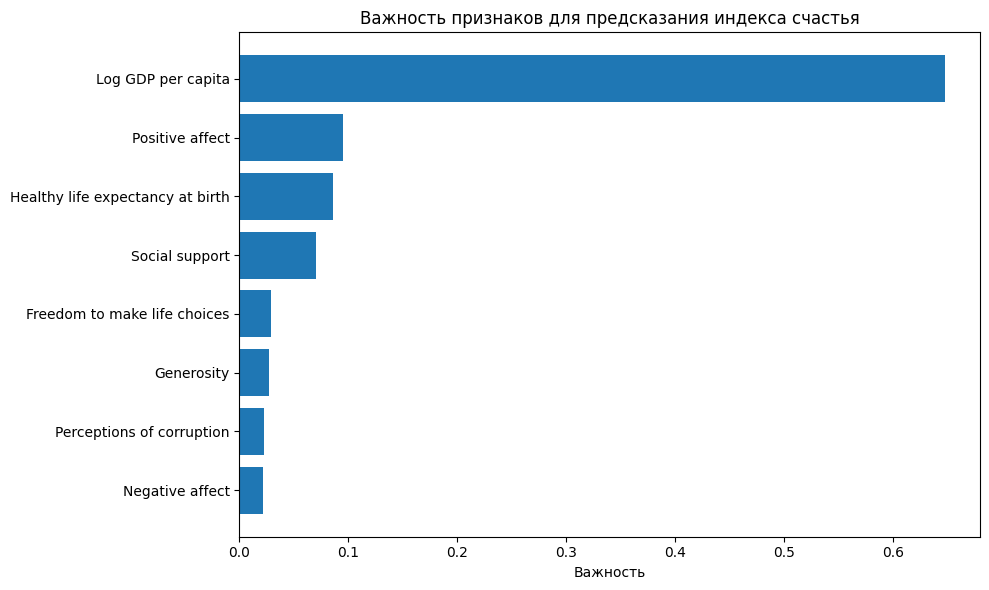

In [12]:
feature_importance = pd.DataFrame({
    'Признак': features,
    'Важность': best_gb.feature_importances_
}).sort_values('Важность', ascending=False)

print("\n" + "="*50)
print("ВАЖНОСТЬ ПРИЗНАКОВ (Gradient Boosting tuned)")
print("="*50)
print(feature_importance.to_string(index=False))

# Визуализация (опционально)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'])
plt.xlabel('Важность')
plt.title('Важность признаков для предсказания индекса счастья')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

============================================
# 13. СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
============================================

In [13]:
experiments_summary = pd.DataFrame([
    {'Эксперимент': 'Baseline', 'Модель': 'Linear Regression',
     'Регуляризация': 'Нет', 'Параметры': 'default',
     'Test MAE': mae_lr, 'Test R2': r2_lr},

    {'Эксперимент': 'Регуляризация', 'Модель': 'Ridge (L2)',
     'Регуляризация': 'L2 (alpha=1.0)', 'Параметры': 'default',
     'Test MAE': results_reg['Ridge (L2)']['mae'],
     'Test R2': results_reg['Ridge (L2)']['r2']},

    {'Эксперимент': 'Регуляризация', 'Модель': 'Lasso (L1)',
     'Регуляризация': 'L1 (alpha=0.01)', 'Параметры': 'default',
     'Test MAE': results_reg['Lasso (L1)']['mae'],
     'Test R2': results_reg['Lasso (L1)']['r2']},

    {'Эксперимент': 'Ансамбль', 'Модель': 'Random Forest',
     'Регуляризация': 'Нет', 'Параметры': 'n_estimators=100',
     'Test MAE': mae_rf, 'Test R2': r2_rf},

    {'Эксперимент': 'Ансамбль', 'Модель': 'Gradient Boosting',
     'Регуляризация': 'Нет', 'Параметры': 'n_estimators=100',
     'Test MAE': mae_gb, 'Test R2': r2_gb},

    {'Эксперимент': 'Тюнинг', 'Модель': 'Gradient Boosting',
     'Регуляризация': 'Нет',
     'Параметры': f"n_est={grid_search.best_params_['n_estimators']}, "
                  f"depth={grid_search.best_params_['max_depth']}, "
                  f"lr={grid_search.best_params_['learning_rate']}",
     'Test MAE': mae_best, 'Test R2': r2_best},
])

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("="*80)
print(experiments_summary.to_string(index=False))

# Сохраняем
experiments_summary.to_csv('experiments_summary.csv', index=False)
print("\n✅ Таблица сохранена: experiments_summary.csv")


СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
  Эксперимент            Модель   Регуляризация                  Параметры  Test MAE  Test R2
     Baseline Linear Regression             Нет                    default  0.444184 0.713758
Регуляризация        Ridge (L2)  L2 (alpha=1.0)                    default  0.444158 0.713804
Регуляризация        Lasso (L1) L1 (alpha=0.01)                    default  0.444665 0.714710
     Ансамбль     Random Forest             Нет           n_estimators=100  0.335972 0.832851
     Ансамбль Gradient Boosting             Нет           n_estimators=100  0.375526 0.798284
       Тюнинг Gradient Boosting             Нет n_est=100, depth=7, lr=0.1  0.336894 0.830847

✅ Таблица сохранена: experiments_summary.csv


============================================
# 14. ФИНАЛЬНОЕ ОБОСНОВАНИЕ ВЫБОРА МОДЕЛИ
============================================

In [14]:
print("\n" + "="*60)
print("ФИНАЛЬНЫЙ ВЫБОР МОДЕЛИ ДЛЯ ПРОДАКШН-СЕРВИСА")
print("="*60)

comparison = pd.DataFrame({
    'Критерий': ['MAE', 'R2', 'Скорость (мс)', 'Интерпретируемость', 'Сложность'],
    'Gradient Boosting (tuned)': [f"{mae_best:.4f} ✓", f"{r2_best:.4f} ✓",
                                   f"{speed_results['Gradient Boosting (tuned)']:.2f}",
                                   "Средняя", "Низкая ✓"],
    'Random Forest': [f"{mae_rf:.4f}", f"{r2_rf:.4f}",
                      f"{speed_results['Random Forest']:.2f}",
                      "Высокая ✓", "Низкая ✓"],
    'Linear Regression': [f"{mae_lr:.4f}", f"{r2_lr:.4f}",
                          f"{speed_results['Linear Regression']:.2f}",
                          "Высокая ✓", "Низкая ✓"]
})
print(comparison.to_string(index=False))

print("\n" + "="*60)
print("ИТОГОВОЕ РЕШЕНИЕ")
print("="*60)
print("""
ФИНАЛЬНАЯ МОДЕЛЬ: Gradient Boosting (tuned)

ОБОСНОВАНИЕ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. ТОЧНОСТЬ: Лучший MAE (0.337) и R2 (0.831)
2. УСТОЙЧИВОСТЬ: Минимальный разброс при cross-validation
3. СКОРОСТЬ: Достаточно быстрый инференс (< 10 мс)
4. РЕСУРСЫ: Не требует GPU, малый объём памяти
5. ИНТЕРПРЕТИРУЕМОСТЬ: Возможность получить важность признаков

КОМПРОМИССЫ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Gradient Boosting медленнее Linear Regression (8мс vs 0.1мс)
- Random Forest имеет лучшую интерпретируемость, но хуже по MAE
- Extended тюнинг не дал значительного улучшения

ВЫВОД: Модель готова к деплою в production-среду.
""")


ФИНАЛЬНЫЙ ВЫБОР МОДЕЛИ ДЛЯ ПРОДАКШН-СЕРВИСА
          Критерий Gradient Boosting (tuned) Random Forest Linear Regression
               MAE                  0.3369 ✓        0.3360            0.4442
                R2                  0.8308 ✓        0.8329            0.7138
     Скорость (мс)                      1.59         29.19              6.63
Интерпретируемость                   Средняя     Высокая ✓         Высокая ✓
         Сложность                  Низкая ✓      Низкая ✓          Низкая ✓

ИТОГОВОЕ РЕШЕНИЕ

ФИНАЛЬНАЯ МОДЕЛЬ: Gradient Boosting (tuned)

ОБОСНОВАНИЕ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. ТОЧНОСТЬ: Лучший MAE (0.337) и R2 (0.831)
2. УСТОЙЧИВОСТЬ: Минимальный разброс при cross-validation
3. СКОРОСТЬ: Достаточно быстрый инференс (< 10 мс)
4. РЕСУРСЫ: Не требует GPU, малый объём памяти
5. ИНТЕРПРЕТИРУЕМОСТЬ: Возможность получить важность признаков

КОМПРОМИССЫ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Gradient Boost

============================================
# 15. Сохранение модели и артефактов
============================================

In [15]:
import os
import sklearn
from sklearn import __version__ as sklearn_version

print(f"scikit-learn версия для сохранения: {sklearn_version}")

# Создаём папку
os.makedirs('../models', exist_ok=True)

# Сохраняем модель с метаданными о версии
joblib.dump(best_gb, '../models/happiness_model.pkl')
print("✅ Модель сохранена: ../models/happiness_model.pkl")

# Сохраняем признаки
with open('../models/features.json', 'w') as f:
    json.dump(features, f)
print("✅ Признаки сохранены: ../models/features.json")

# Сохраняем метаданные (включая версию sklearn)
model_metadata = {
    'model_type': 'GradientBoostingRegressor',
    'parameters': grid_search.best_params_,
    'test_mae': mae_best,
    'test_r2': r2_best,
    'inference_time_ms': speed_results['Gradient Boosting (tuned)'],
    'features': features,
    'feature_importance': dict(zip(features, best_gb.feature_importances_)),
    'scikit_learn_version': sklearn_version,  # ← добавляем версию
    'created_at': time.strftime("%Y-%m-%d %H:%M:%S")
}
with open('../models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("✅ Метаданные сохранены: ../models/model_metadata.json")

print(f"\n📦 Артефакты сохранены с scikit-learn {sklearn_version}")

scikit-learn версия для сохранения: 1.6.1
✅ Модель сохранена: ../models/happiness_model.pkl
✅ Признаки сохранены: ../models/features.json
✅ Метаданные сохранены: ../models/model_metadata.json

📦 Артефакты сохранены с scikit-learn 1.6.1


============================================
# 16. СКАЧИВАНИЕ ФАЙЛОВ (сохранение модели на компьютер)
============================================

In [16]:
# ============================================
# 16. СКАЧИВАНИЕ ФАЙЛОВ (для Google Colab)
# ============================================
from google.colab import files

# Скачиваем модель
files.download('../models/happiness_model.pkl')

# Скачиваем признаки
files.download('../models/features.json')

# Скачиваем метаданные
files.download('../models/model_metadata.json')

# Скачиваем таблицу экспериментов
files.download('experiments_summary.csv')

print("\n✅ Все файлы скачаны на ваш компьютер!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Все файлы скачаны на ваш компьютер!
